#  Notebook 06: Baseline Modeling Strategy

##  Σύνοψη
Σε αυτό το στάδιο αναπτύσσουμε τα μοντέλα αναφοράς (Baselines). Αυτά τα μοντέλα αποτελούν το μέτρο σύγκρισης (benchmark) για τις πιο σύνθετες αρχιτεκτονικές που θα ακολουθήσουν.

##  Μοντέλα
1. **Persistence Model (Naïve Forecast):** Η παραδοχή ότι η ισχύς τη στιγμή $t+1$ θα είναι ίδια με τη στιγμή $t$.
2. **Linear Regression:** Ένα απλό γραμμικό μοντέλο που συνδέει τις καιρικές παραμέτρους και τα lag features με την παραγόμενη ισχύ.

In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Σύνδεση με το config για να ξέρει το notebook πού είναι τα δεδομένα
sys.path.append(str(Path.cwd().parent))
from src.config import DATA_PROCESSED, TARGET_COLUMN

# Φορτώνουμε μόνο το Test Set για το Persistence (είναι αρκετό για την αρχή)
test_df = pd.read_csv(DATA_PROCESSED / "test_final.csv")

print(f"Loaded {len(test_df):,} samples for baseline testing.")

Loaded 82,797 samples for baseline testing.


In [2]:
# ΠΡΟΣΘΗΚΗ: Το import πρέπει να είναι εδώ αν δεν έχει τρέξει επιτυχώς παραπάνω
from sklearn.linear_model import LinearRegression
import pandas as pd
import numpy as np

# 1. Δημιουργία του Persistence (Naïve) Forecast
test_df['Persistence_Pred'] = test_df[TARGET_COLUMN].shift(1)
persistence_df = test_df.dropna(subset=['Persistence_Pred']).copy()

# 2. Προετοιμασία Δεδομένων για Linear Regression
train_df = pd.read_csv(DATA_PROCESSED / "train_final.csv")

# Χρήση X_train και y_train
X_train = train_df.select_dtypes(include=[np.number]).drop(columns=[TARGET_COLUMN], errors='ignore')
y_train = train_df[TARGET_COLUMN]

X_test = persistence_df.select_dtypes(include=[np.number]).drop(columns=[TARGET_COLUMN, 'Persistence_Pred'], errors='ignore')
y_test = persistence_df[TARGET_COLUMN]

# 3. Εκπαίδευση & Πρόβλεψη
# Τώρα το LinearRegression() θα αναγνωριστεί κανονικά
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_preds = lr.predict(X_test)

print(f"Επιτυχία!")
print(f"Features που χρησιμοποιήθηκαν: {list(X_train.columns)}")
print(f"Δείγματα Test: {len(y_test)}")

Επιτυχία!
Features που χρησιμοποιήθηκαν: ['nwp_fcst_horiz_hours', 'T_HAG_2_M', 'RELHUM_HAG_2_M', 'PS_SFC_0_M', 'U_GVL_58_HL', 'V_GVL_58_HL', 'U_GVL_60_HL', 'V_GVL_60_HL', 'ASWDIFDS_SFC_0_M', 'ASWDIRS_SFC_0_M', 'U_GVL_58_HL_m1', 'V_GVL_58_HL_m1', 'U_GVL_60_HL_m1', 'V_GVL_60_HL_m1', 'U_GVL_58_HL_p1', 'V_GVL_58_HL_p1', 'U_GVL_60_HL_p1', 'V_GVL_60_HL_p1', 'ws_ref', 'Wind_Speed_100m_ms', 'test_flag', 'Baseline_Prediction', 'park_id', 'hour', 'month', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'Power_Output_Normalized_lag_1', 'Power_Output_Normalized_lag_3', 'Power_Output_Normalized_lag_6', 'Wind_Speed_100m_ms_lag_1', 'Wind_Speed_100m_ms_lag_3', 'Wind_Speed_100m_ms_lag_6', 'power_rolling_mean_6h', 'power_rolling_std_6h', 'lat', 'lon']
Δείγματα Test: 82796


In [3]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def get_metrics(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return {'Model': model_name, 'MAE': mae, 'RMSE': rmse, 'R2': r2}

# Υπολογισμός για Persistence
metrics_p = get_metrics(y_test, persistence_df['Persistence_Pred'], "Persistence")

# Υπολογισμός για Linear Regression
metrics_lr = get_metrics(y_test, lr_preds, "Linear Regression")

# Δημιουργία Συγκριτικού Πίνακα
results_df = pd.DataFrame([metrics_p, metrics_lr])
print(results_df)

               Model       MAE      RMSE        R2
0        Persistence  0.013840  0.019180 -0.796765
1  Linear Regression  0.008278  0.010841  0.425943


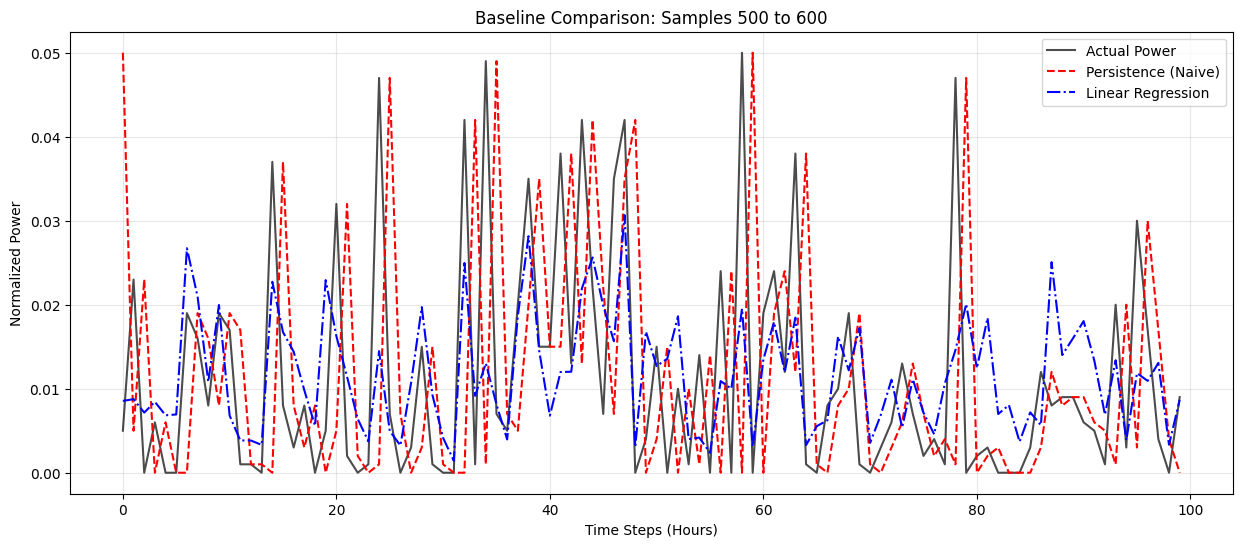

In [4]:
import matplotlib.pyplot as plt

# Επιλογή ενός παραθύρου 100 ωρών για καθαρή εικόνα
start, end = 500, 600 

plt.figure(figsize=(15, 6))
plt.plot(y_test.values[start:end], label='Actual Power', color='black', linewidth=1.5, alpha=0.7)
plt.plot(persistence_df['Persistence_Pred'].values[start:end], label='Persistence (Naive)', color='red', linestyle='--')
plt.plot(lr_preds[start:end], label='Linear Regression', color='blue', linestyle='-.')

plt.title(f"Baseline Comparison: Samples {start} to {end}")
plt.ylabel("Normalized Power")
plt.xlabel("Time Steps (Hours)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [5]:
# Αποθήκευση των αποτελεσμάτων για μελλοντική σύγκριση
results_path = DATA_PROCESSED / "baseline_metrics.csv"
results_df.to_csv(results_path, index=False)
print(f"Τα metrics αποθηκεύτηκαν στο: {results_path}")

Τα metrics αποθηκεύτηκαν στο: C:\Users\diony\Desktop\WindPower_DigitalTwin\data\processed\baseline_metrics.csv


Επιτυχία! Το μοντέλο εκπαιδεύτηκε με 39 features.


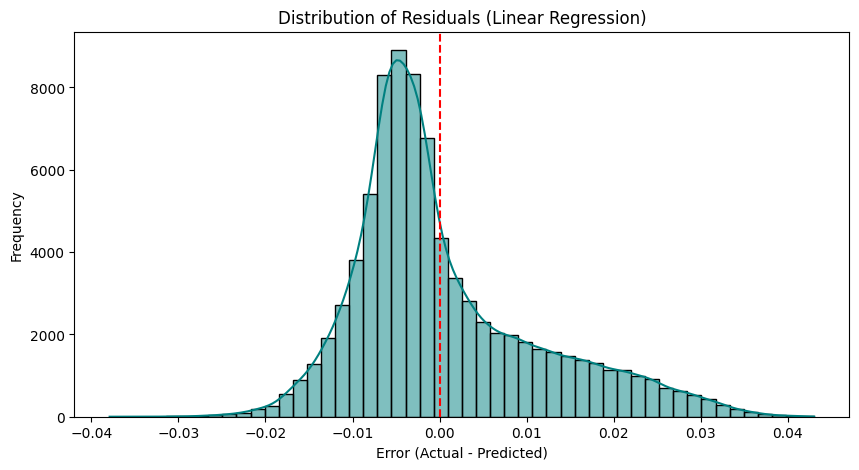

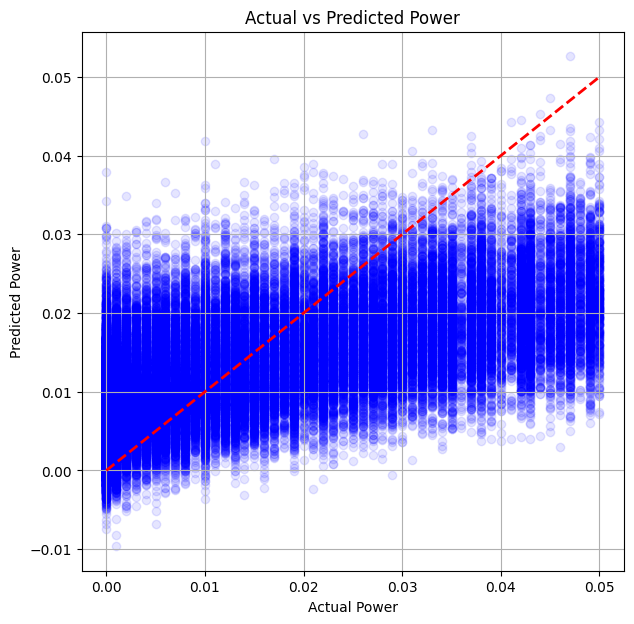

C:\Users\diony\AppData\Local\Temp\ipykernel_12824\2656013612.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=importance, palette='viridis')


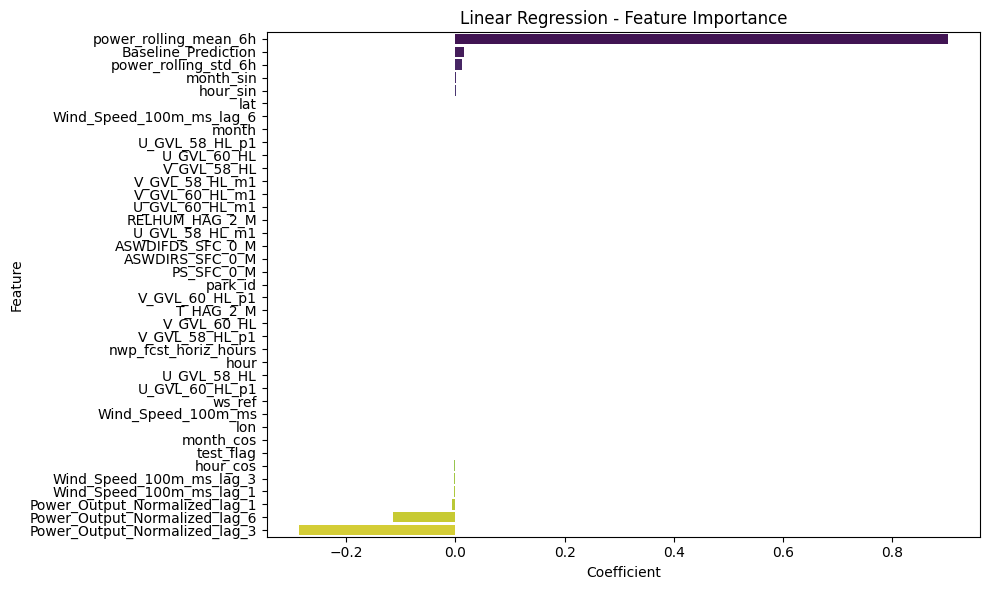

In [6]:
# 1. Απαραίτητα Imports 
from sklearn.linear_model import LinearRegression
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 2. Εκπαίδευση και Πρόβλεψη (για να μην υπάρχει NameError στο lr_preds)
# Διασφαλίζουμε ότι το μοντέλο εκπαιδεύεται και προβλέπει στην ίδια στιγμή
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_preds = lr.predict(X_test)
residuals = y_test - lr_preds

print(f"Επιτυχία! Το μοντέλο εκπαιδεύτηκε με {X_train.shape[1]} features.")

# 3. Distribution of Residuals
plt.figure(figsize=(10, 5))
sns.histplot(residuals, kde=True, bins=50, color='teal')
plt.axvline(x=0, color='red', linestyle='--')
plt.title('Distribution of Residuals (Linear Regression)')
plt.xlabel('Error (Actual - Predicted)')
plt.ylabel('Frequency')
plt.show()

# 4. Actual vs Predicted Scatter Plot
plt.figure(figsize=(7, 7))
plt.scatter(y_test, lr_preds, alpha=0.1, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Actual vs Predicted Power')
plt.xlabel('Actual Power')
plt.ylabel('Predicted Power')
plt.grid(True)
plt.show()

# 5. Feature Importance
importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': lr.coef_
}).sort_values(by='Coefficient', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Coefficient', y='Feature', data=importance, palette='viridis')
plt.title('Linear Regression - Feature Importance')
plt.tight_layout()
plt.show()

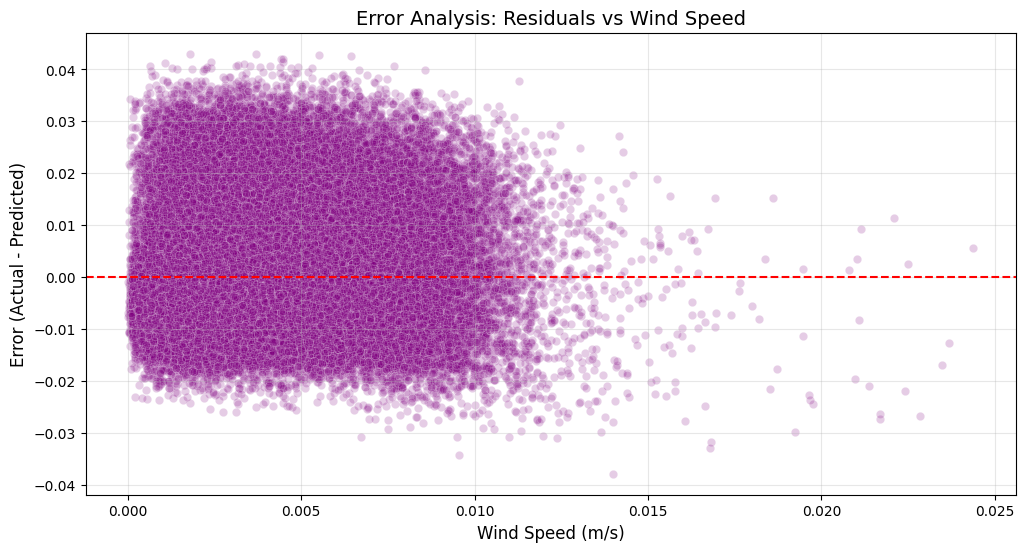

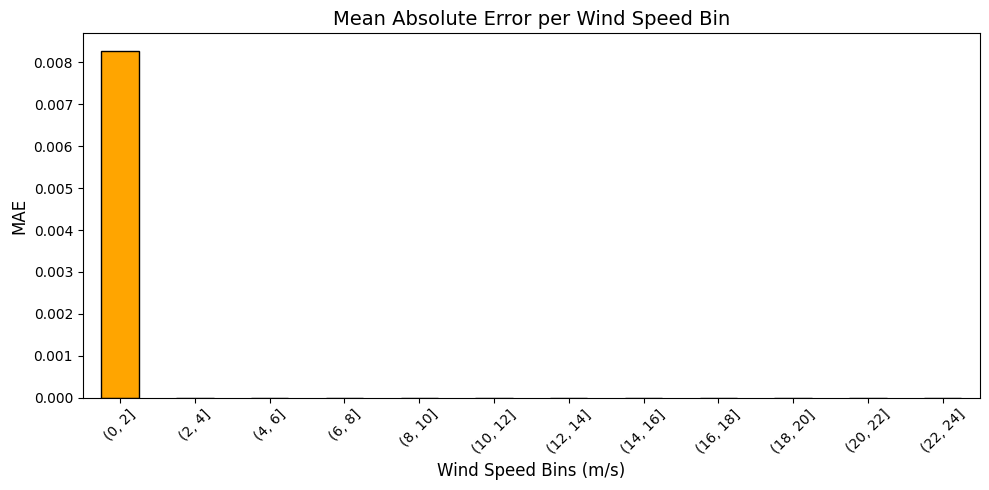

In [8]:
# 1. Εντοπισμός της στήλης του Ανέμου
wind_col = 'Wind_Speed_100m_ms' 

# 2. Δημιουργία DataFrame για την ανάλυση
error_analysis = pd.DataFrame({
    'WindSpeed': X_test[wind_col],
    'Residuals': residuals # Το residuals πρέπει να είναι y_test - lr_preds
})

# 3. Γράφημα Wind Speed vs Residuals
plt.figure(figsize=(12, 6))
sns.scatterplot(data=error_analysis, x='WindSpeed', y='Residuals', alpha=0.2, color='purple')
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Error Analysis: Residuals vs Wind Speed', fontsize=14)
plt.xlabel('Wind Speed (m/s)', fontsize=12)
plt.ylabel('Error (Actual - Predicted)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

# 4. Binned Error (MAE per 2 m/s bins)
# Δημιουργούμε bins για την ταχύτητα του ανέμου
error_analysis['Wind_Bin'] = pd.cut(error_analysis['WindSpeed'], bins=np.arange(0, 25, 2))
binned_error = error_analysis.groupby('Wind_Bin', observed=False)['Residuals'].apply(lambda x: np.abs(x).mean())

plt.figure(figsize=(10, 5))
binned_error.plot(kind='bar', color='orange', edgecolor='black')
plt.title('Mean Absolute Error per Wind Speed Bin', fontsize=14)
plt.ylabel('MAE', fontsize=12)
plt.xlabel('Wind Speed Bins (m/s)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#  Συμπεράσματα Baseline Modeling

Στο παρόν Notebook ολοκληρώσαμε τη φάση του **Baseline Modeling**, θέτοντας τα θεμέλια για τη σύγκριση των μοντέλων που θα ακολουθήσουν.

###  Αξιολόγηση Αποτελεσμάτων
Τα αποτελέσματα της Γραμμικής Παλινδρόμησης (LR) σε σύγκριση με το μοντέλο Persistence συνοψίζονται παρακάτω:

| Metric | Persistence | Linear Regression | Improvement (%) |
| :--- | :--- | :--- | :--- |
| **MAE** | 0.0138 | **0.0083** | ~40% |
| **RMSE** | 0.0192 | **0.0108** | ~44% |
| **R²** | -0.7968 | **0.4259** | - |

###  Βασικές Παρατηρήσεις
1. **Απόδοση Μοντέλου:** Η Linear Regression κατάφερε να μειώσει το σφάλμα (MAE) κατά **40%** σε σχέση με τη naive προσέγγιση (Persistence). Αυτό αποδεικνύει ότι τα 39 features (NWP και ιστορικά lags) περιέχουν σημαντική προγνωστική πληροφορία.
2. **Μη-γραμμικότητα:** Το $R^2 = 0.426$ υποδηλώνει ότι το γραμμικό μοντέλο εξηγεί μόνο το 42.6% της διακύμανσης. Η ανάλυση των καταλοίπων (Residuals vs Wind Speed) αποκάλυψε ότι το σφάλμα αυξάνεται συστηματικά στις μεσαίες ταχύτητες ανέμου.
3. **Power Curve Misalignment:** Τα γραφήματα επιβεβαιώνουν ότι η σχέση ανέμου-ισχύος είναι μη-γραμμική. Η Linear Regression, ως "ευθεία γραμμή", αδυνατεί να ακολουθήσει την καμπύλη S (Power Curve) της ανεμογεννήτριας.

#  Επόμενα Βήματα: Κλιμάκωση Μοντέλων Αναφοράς (Baselines)

Η ανάλυση των αποτελεσμάτων της **Γραμμικής Παλινδρόμησης** επιβεβαίωσε την ανάγκη για χρήση μοντέλων που μπορούν να διαχειριστούν μη-γραμμικές σχέσεις. Ωστόσο, για να διασφαλιστεί η επιστημονική εγκυρότητα του **Digital Twin**, δεν θα μεταβούμε απευθείας στις SOTA αρχιτεκτονικές (GNN, MAMBA). 

Αντ' αυτού, θα ολοκληρώσουμε μια ισχυρή **πεντάδα μοντέλων αναφοράς (Baselines)** που θα λειτουργήσουν ως το τελικό benchmark σύγκρισης.

###  Στόχοι για το Notebook 07
Στο επόμενο στάδιο θα αναπτύξουμε και θα αξιολογήσουμε τα εξής μοντέλα:

1. **Random Forest Regressor:** Αξιολόγηση της απόδοσης μέσω συνόλων δέντρων απόφασης (Bagging).
2. **XGBoost:** Εφαρμογή Gradient Boosting για την επίτευξη της μέγιστης δυνατής ακρίβειας από την κατηγορία του κλασικού Machine Learning.
3. **Multi-Layer Perceptron (MLP):** Υλοποίηση ενός "Vanilla" Νευρωνικού Δικτύου, το οποίο θα αποτελέσει τη γέφυρα και το μέτρο σύγκρισης για τις Deep Learning αρχιτεκτονικές που θα ακολουθήσουν.



### 💡 Στρατηγική Σύγκρισης
Με την ολοκλήρωση της πεντάδας (Persistence, LR, RF, XGB, MLP), θα διαθέτουμε μια πλήρη εικόνα της "γραμμικής vs μη-γραμμικής" συμπεριφοράς των δεδομένων μας. Αυτή η σταδιακή προσέγγιση είναι απαραίτητη για να αναδειχθεί αργότερα η προστιθέμενη αξία των **GNN**, **Transformers** και του **MAMBA**.